<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=294712333" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090001,2026-01-24,0002082542,2025-09-30,0.000225,NaN,NaN,NaN,-0.000017,-0.000027,0.000064,...,NaN,NaN,NaN,NaN,NaN,BIXI,NASDAQ,NaN,NaN,116
1090002,2026-01-24,0002082844,2025-09-30,0.000197,NaN,NaN,NaN,-0.000034,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,SAC-U,NYSE,NaN,NaN,116
1090003,2026-01-24,0002084563,2025-09-30,0.000295,NaN,NaN,NaN,-0.000036,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,LFAC,NASDAQ,NaN,NaN,116
1090004,2026-01-24,0002088749,2025-09-30,0.000676,NaN,NaN,NaN,-0.000032,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,KBON,NASDAQ,NaN,NaN,116


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)

# There are 100+ ciks that report too infrequently, i.e. less than 4 times a year.
# These are mostly foreign (non-US) entities that nevertheless trade on US exchanges.
# Whatever the cause, ciks that report less often than 4 times a year distort the model and we
# remove them. We determine the reporting frequency by the unique Asset values reported per year.
too_few_reports = snapshots[['Assets']].dropna()
too_few_reports['year'] = pd.to_datetime(too_few_reports.index.get_level_values(0)).year
too_few_reports = too_few_reports.groupby(by=['cik','year'])['Assets'].nunique().groupby('cik').max()
too_few_reports = snapshots.loc[(slice(None),too_few_reports[too_few_reports<4].index),:].index
snapshots = snapshots.drop(index=too_few_reports)

snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-01-24 0001905956 2025-09-30    TGL   0.016595     0.004622   
           0001906324 2025-09-28   QDEL   5.675100     3.638700   
           0001907982 2025-09-30   QBTS   0.865820     0.195266   
           0001914605 2025-09-30   ECBK   1.552653     1.383344   
           0001915657 2025-09-30   DINO  17.264000     7.834000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-01-24 0001905956 2025-09-30             -0.010266    NaN  
           0001906324 2025-09-28              0.037000    NaN  
           0001907982 2025-09-30             -0.051593    NaN  
           0001914605 2025-09-30              0.009768    NaN  
           0001915657 2025-09-30              1.167000    NaN  

[437897 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3213 unique ciks for a total of 542997 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[542997 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [9]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [10]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3213, 169, 3])
Labels shape: torch.Size([3213, 169])
Asset multiplier shape: torch.Size([3213])
Cash multiplier shape: torch.Size([169])


device(type='cpu')

Adjusted assets shape: torch.Size([3213, 169])
Adjusted cashflow shape: torch.Size([3213, 169])
Forward shape: torch.Size([3213, 169])
Epoch [1000/6000], Loss=935.81037975
Epoch [2000/6000], Loss=934.78775318
Epoch [3000/6000], Loss=934.65426862
Epoch [4000/6000], Loss=934.68759550
Epoch [5000/6000], Loss=934.65474898
Epoch [6000/6000], Loss=934.39987058


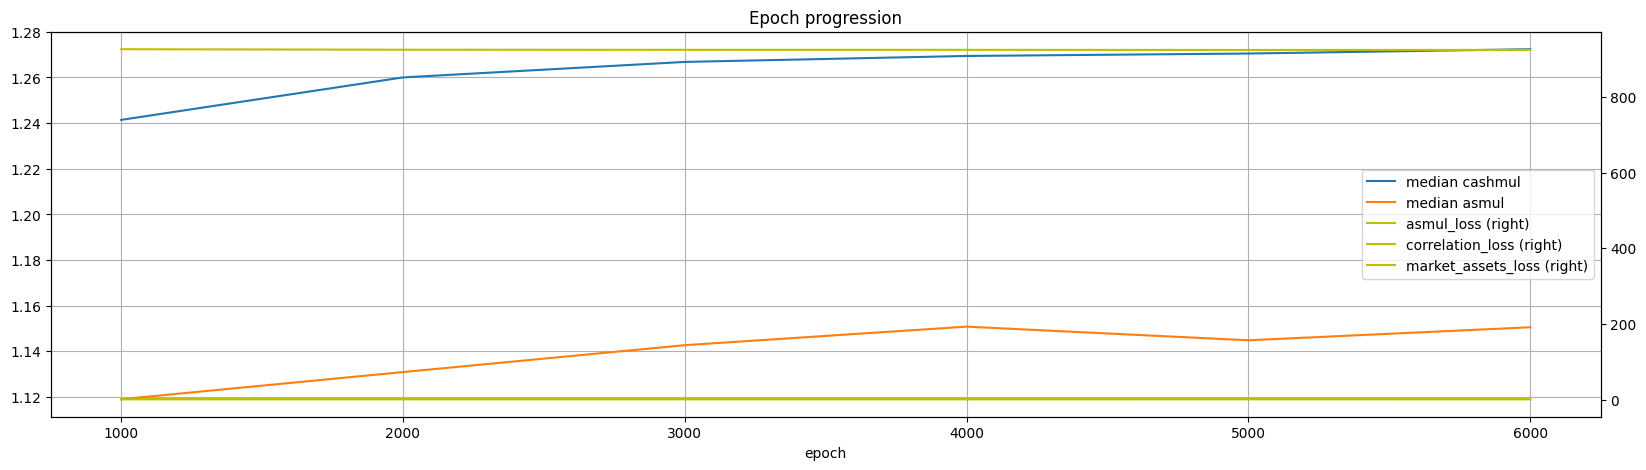

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.241423,1.119037,0.879181,926.141355,0.877217
2000,1.260029,1.130932,0.906575,924.844359,0.877649
3000,1.266814,1.142716,0.926773,924.540614,0.845930
4000,1.269422,1.150834,0.932147,924.532203,0.833920
5000,1.270491,1.144859,0.942834,924.192932,1.033478
6000,1.272379,1.150569,0.921138,924.295671,0.892816


In [11]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [12]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  1.005089 -1.177881  0.774761  
           2012-02-01  1.005089 -1.050753  0.785387  
           2012-03-01  1.005089 -0.976191  0.791620  
           2012-04-01  1.005089 -0.903641  0.840927  
           2012-05-01  1.005089 -0.926214  0.839416  
...                         ...       ...       ...  
0001915657 2025-09-01  0.830174  1.616930  8.146886  
           2025-10-01  0.830174  1.604716  8.133853  
           2025-11-01  0.830174  1.482360  8.228039  
           2025-12-01  0.830174  1.522810  8.275244  
           2026-01-01  0.830174  1.527980  8.281277  

[422244 rows x 7 columns]

In [13]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['slope'] = regressor.coef_[0]
    df['intercept'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept
snapshot,cik,date,,,,,,,,,,
2024-07-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,193.25,0.586465,1.289550,202.280859,0.565174,48.013052
2024-08-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,186.98,0.586465,1.555243,244.558060,0.565174,48.013052
2024-09-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,178.50,0.586465,1.583870,287.497908,0.565174,48.013052
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.586465,1.619230,293.759764,0.565174,48.013052
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.586465,1.544584,280.540641,0.565174,48.013052
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.586465,1.822808,370.909129,0.565174,48.013052
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.586465,1.545920,317.208475,0.565174,48.013052
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.586465,1.629248,333.369480,0.565174,48.013052
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.586465,1.544067,331.912132,0.565174,48.013052


Let's examine the achieved correlations using a histogram:

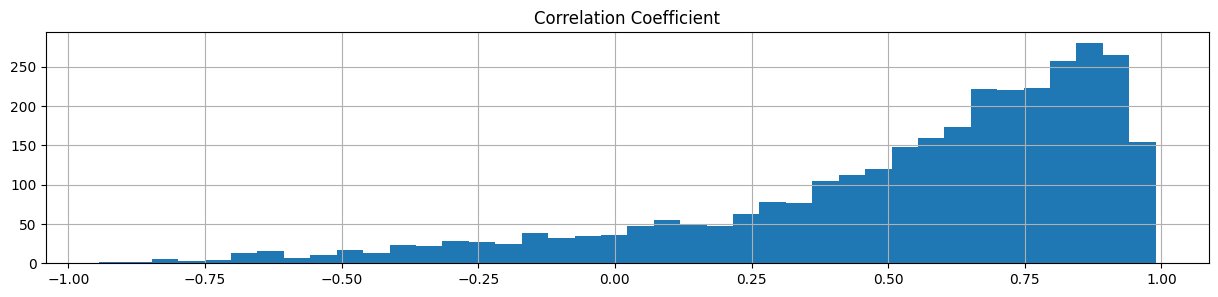

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

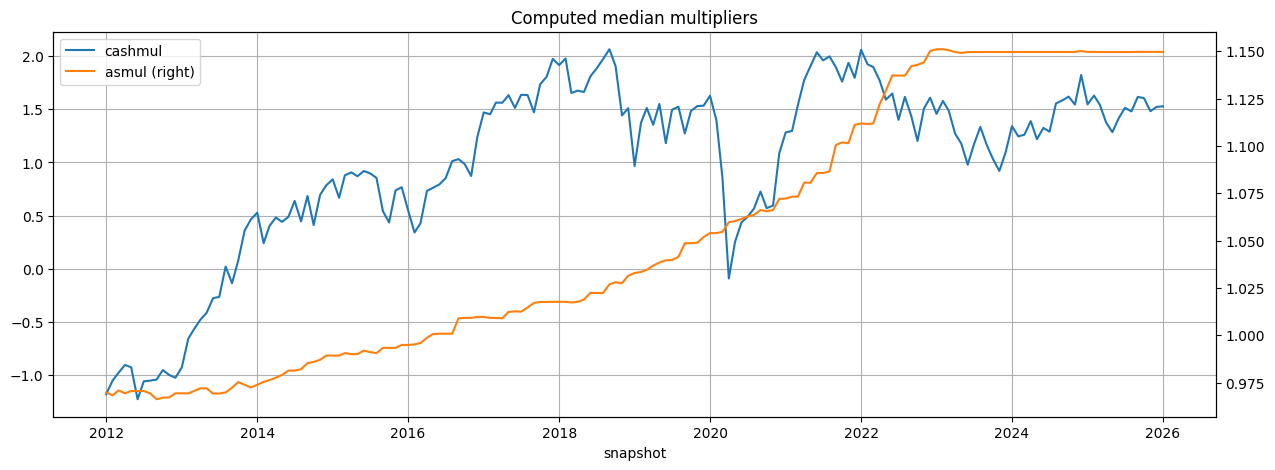

Median asset_multiplier per cik: 1.1505688428878784
Median asset_multiplier per snapshot: 1.0329104661941528


In [15]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [16]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

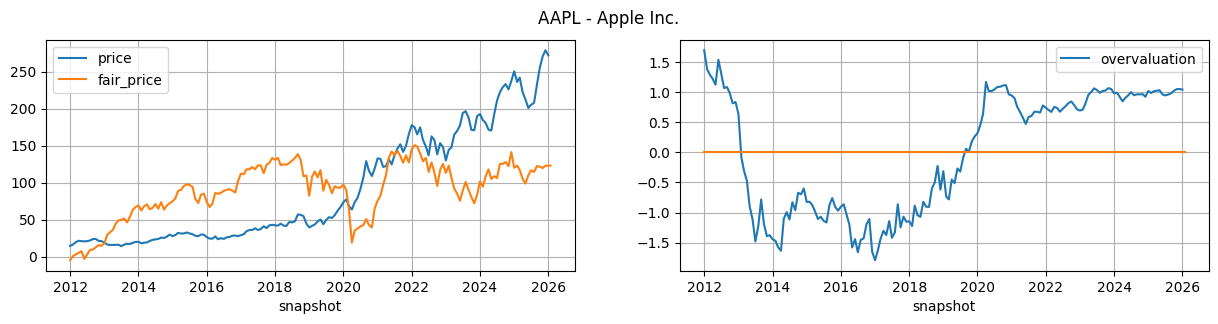

AAPL fair_price = 0.650570 * (0.937822 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -21.268386


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320193,2025-06-28,AAPL,331.495,265.665,108.565,0.937822,1.604716,0.65057,-21.268386,219.434239,121.489042
2025-11-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.937822,1.482360,0.65057,-21.268386,216.652544,119.679353
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.937822,1.522810,0.65057,-21.268386,221.161975,122.613055
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.937822,1.527980,0.65057,-21.268386,221.738309,122.988001
2026-01-24,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.937822,1.527980,0.65057,-21.268386,221.738309,122.988001


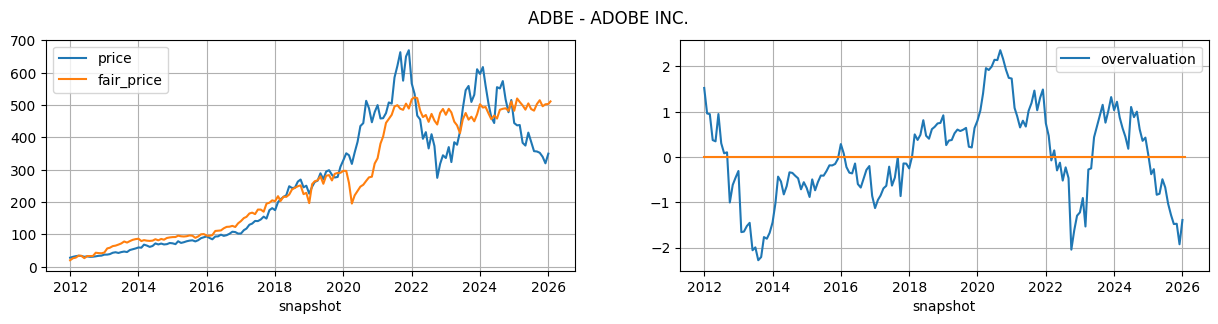

ADBE fair_price = 15.573788 * (1.407266 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -95.200617


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.407266,1.604716,15.573788,-95.200617,39.193893,515.196772
2025-11-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.407266,1.482360,15.573788,-95.200617,37.995786,496.537707
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.407266,1.522810,15.573788,-95.200617,38.391871,502.706251
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.407266,1.527980,15.573788,-95.200617,38.442493,503.494630
2026-01-24,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.407266,1.527980,15.573788,-95.200617,38.962871,511.598891


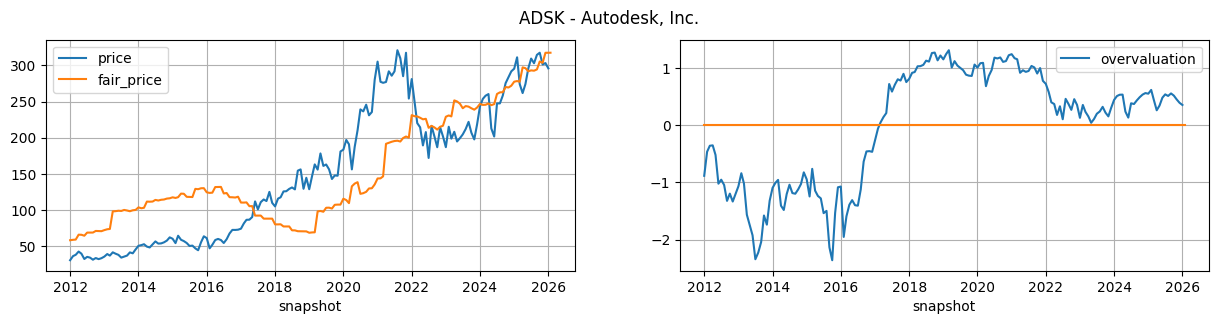

ADSK fair_price = 7.704250 * (4.498613 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -31.831844


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.498613,1.604716,7.70425,-31.831844,43.785019,305.498892
2025-11-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.498613,1.482360,7.70425,-31.831844,43.549484,303.684273
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.498613,1.522810,7.70425,-31.831844,45.352122,317.572246
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.498613,1.527980,7.70425,-31.831844,45.363263,317.658078
2026-01-24,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.498613,1.527980,7.70425,-31.831844,45.363263,317.658078


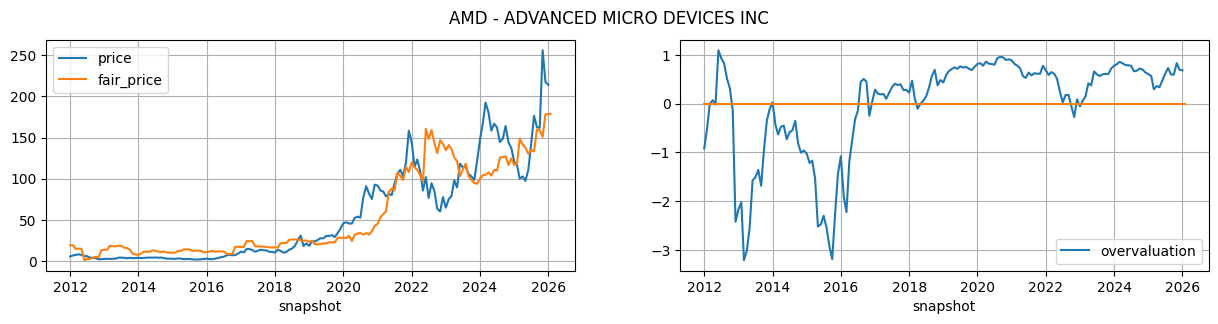

AMD fair_price = 13.720232 * (0.202108 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +52.106880


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.202108,1.604716,13.720232,52.10688,7.792910,159.027410
2025-11-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.202108,1.482360,13.720232,52.10688,7.196181,150.840153
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202108,1.522810,13.720232,52.10688,9.197442,178.297922
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202108,1.527980,13.720232,52.10688,9.230570,178.752442
2026-01-24,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202108,1.527980,13.720232,52.10688,9.230570,178.752442


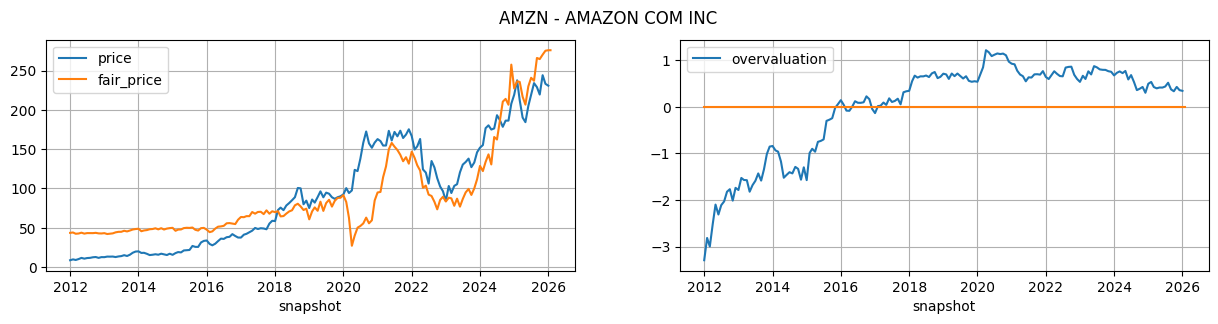

AMZN fair_price = 0.565174 * (0.586465 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +48.013052


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001018724,2025-06-30,AMZN,682.170,348.395,206.735833,0.586465,1.604716,0.565174,48.013052,383.426068,264.715512
2025-11-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.586465,1.482360,0.565174,48.013052,393.395515,270.349985
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.586465,1.522810,0.565174,48.013052,402.258085,275.358880
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.586465,1.527980,0.565174,48.013052,403.390778,275.999048
2026-01-24,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.586465,1.527980,0.565174,48.013052,403.390778,275.999048


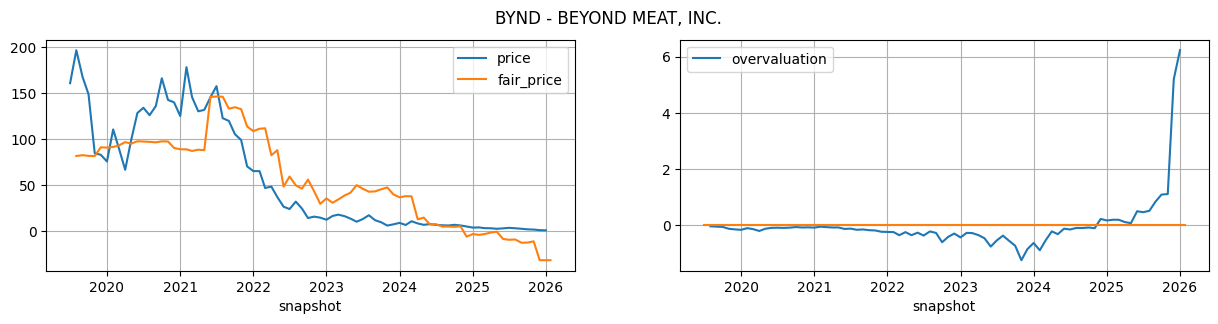

BYND fair_price = 101.593553 * (1.700243 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.042742


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.700243,1.604716,101.593553,25.042742,-0.369723,-12.518732
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.700243,1.482360,101.593553,25.042742,-0.356221,-11.146971
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.700243,1.522810,101.593553,25.042742,-0.557685,-31.614447
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.700243,1.527980,101.593553,25.042742,-0.558342,-31.681197
2026-01-24,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.700243,1.527980,101.593553,25.042742,-0.558342,-31.681197


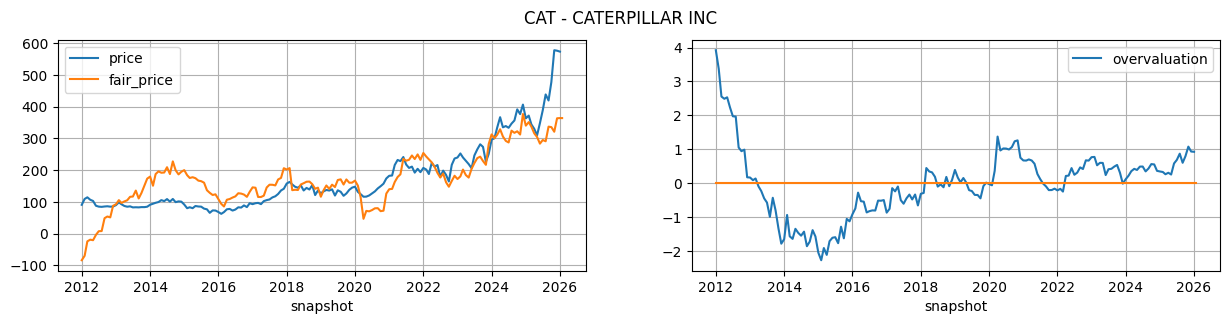

CAT fair_price = 10.467511 * (1.392873 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -422.628785


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.392873,1.604716,10.467511,-422.628785,72.399701,335.215885
2025-11-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.392873,1.482360,10.467511,-422.628785,71.008149,320.649805
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.392873,1.522810,10.467511,-422.628785,75.054608,363.006154
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.392873,1.527980,10.467511,-422.628785,75.114272,363.630688
2026-01-24,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.392873,1.527980,10.467511,-422.628785,75.114272,363.630688


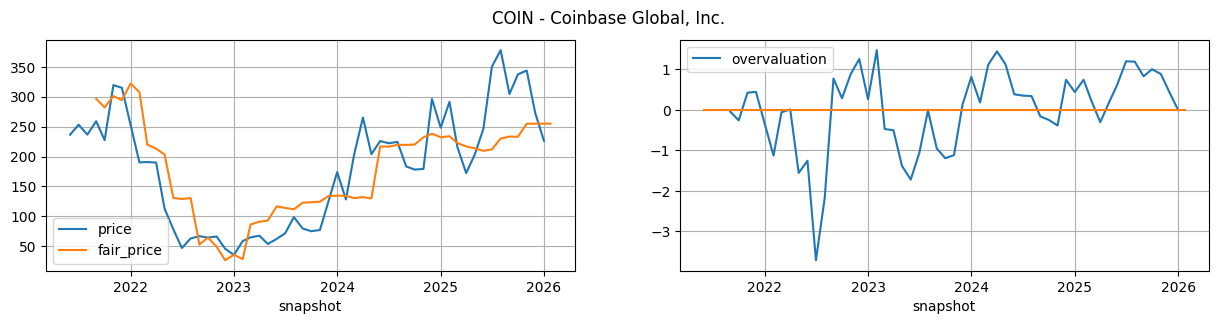

COIN fair_price = 13.373962 * (1.014030 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.147311


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,1.01403,1.604716,13.373962,28.147311,15.323830,233.087629
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.01403,1.482360,13.373962,28.147311,16.946106,254.783894
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.01403,1.522810,13.373962,28.147311,16.959287,254.960170
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.01403,1.527980,13.373962,28.147311,16.960971,254.982700
2026-01-24,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.01403,1.527980,13.373962,28.147311,16.960971,254.982700


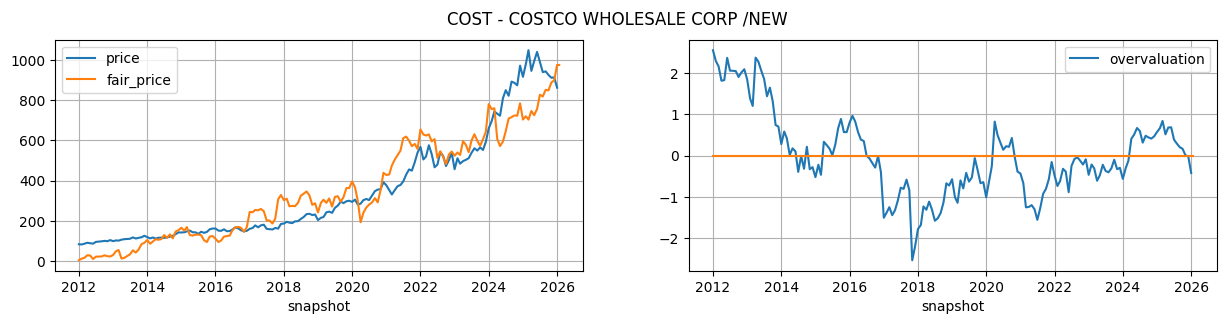

COST fair_price = 19.542686 * (1.092325 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -207.114877


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000909832,2025-05-11,COST,75.482,48.357,12.426,1.092325,1.604716,19.542686,-207.114877,54.034107,848.856693
2025-11-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.092325,1.482360,19.542686,-207.114877,56.049470,888.242310
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.092325,1.522810,19.542686,-207.114877,56.588869,898.783612
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.092325,1.527980,19.542686,-207.114877,60.504187,975.299434
2026-01-24,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.092325,1.527980,19.542686,-207.114877,60.504187,975.299434


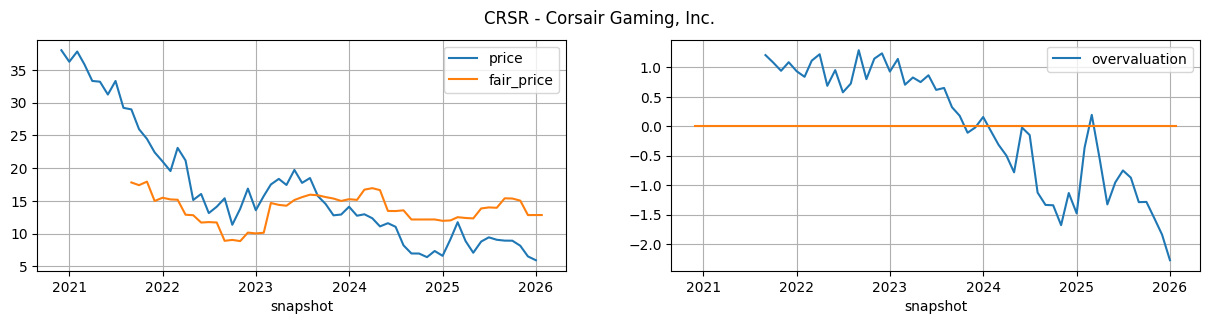

CRSR fair_price = 20.060237 * (1.732938 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -18.897587


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.732938,1.604716,20.060237,-18.897587,1.707429,15.353835
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.732938,1.482360,20.060237,-18.897587,1.691571,15.035736
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.732938,1.522810,20.060237,-18.897587,1.581456,12.826786
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.732938,1.527980,20.060237,-18.897587,1.581805,12.833787
2026-01-24,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.732938,1.527980,20.060237,-18.897587,1.581805,12.833787


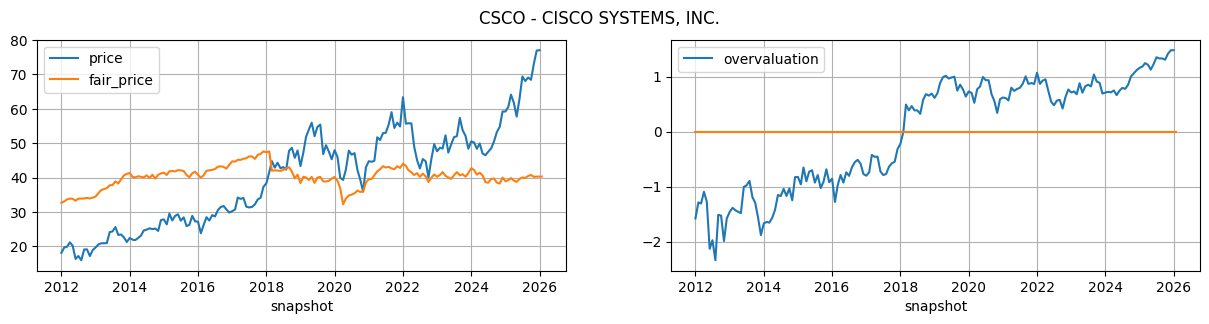

CSCO fair_price = 0.313990 * (0.736718 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.989934


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.736718,1.604716,0.31399,28.989934,37.421740,40.739992
2025-11-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.736718,1.482360,0.31399,28.989934,35.685146,40.194719
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.736718,1.522810,0.31399,28.989934,35.918551,40.268006
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.736718,1.527980,0.31399,28.989934,35.989604,40.290316
2026-01-24,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.736718,1.527980,0.31399,28.989934,35.989604,40.290316


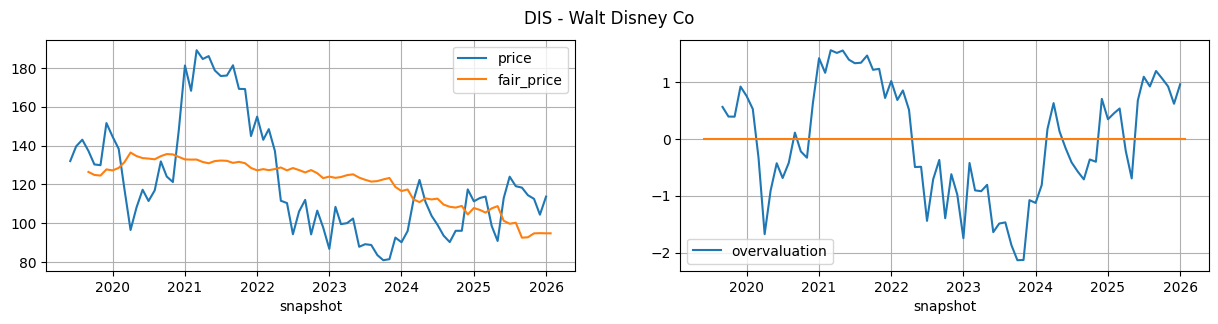

DIS fair_price = -0.856673 * (0.956180 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +205.291420


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.95618,1.604716,-0.856673,205.29142,131.251693,92.851590
2025-11-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.95618,1.482360,-0.856673,205.29142,128.909193,94.858347
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.95618,1.522810,-0.856673,205.29142,128.778266,94.970509
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.95618,1.527980,-0.856673,205.29142,128.871844,94.890343
2026-01-24,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.95618,1.527980,-0.856673,205.29142,128.871844,94.890343


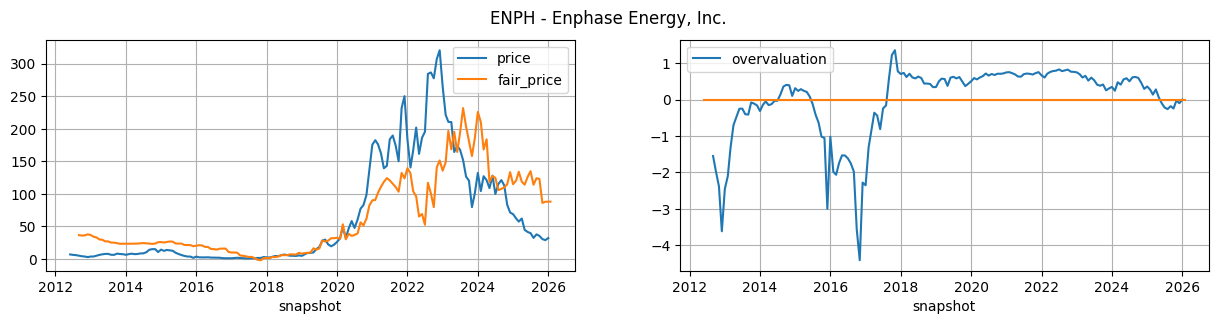

ENPH fair_price = 175.466688 * (0.694354 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +22.812011


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.694354,1.604716,175.466688,22.812011,0.570956,122.995782
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.694354,1.482360,175.466688,22.812011,0.359989,85.978036
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.694354,1.522810,175.466688,22.812011,0.370354,87.796818
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.694354,1.527980,175.466688,22.812011,0.371679,88.029270
2026-01-24,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.694354,1.527980,175.466688,22.812011,0.371679,88.029270


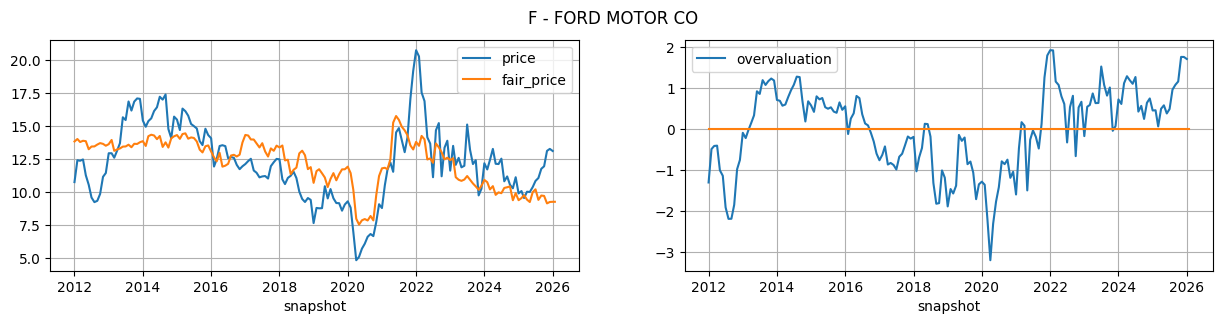

F fair_price = 0.130425 * (0.124910 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.366878


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000037996,2025-06-30,F,292.725,247.668,18.526,0.12491,1.604716,0.130425,33.366878,-181.374819,9.711107
2025-11-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.12491,1.482360,0.130425,33.366878,-185.722717,9.144034
2025-12-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.12491,1.522810,0.130425,33.366878,-184.896489,9.251794
2026-01-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.12491,1.527980,0.130425,33.366878,-184.790891,9.265567
2026-01-24,0000037996,2025-09-30,F,300.990,253.598,20.426,0.12491,1.527980,0.130425,33.366878,-184.790891,9.265567


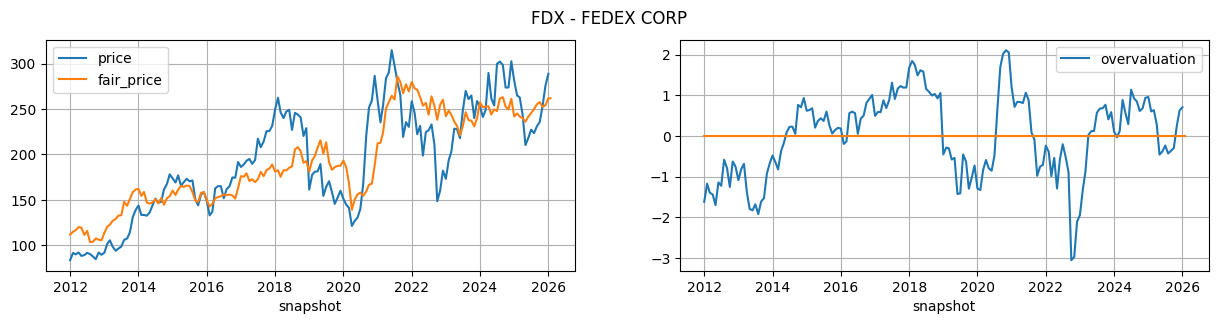

FDX fair_price = 5.809805 * (0.936443 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +58.500904


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.936443,1.604716,5.809805,58.500904,34.291258,257.726420
2025-11-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.936443,1.482360,5.809805,58.500904,33.365637,252.348744
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.936443,1.522810,5.809805,58.500904,33.671641,254.126562
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.936443,1.527980,5.809805,58.500904,34.998340,261.834427
2026-01-24,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.936443,1.527980,5.809805,58.500904,34.998340,261.834427


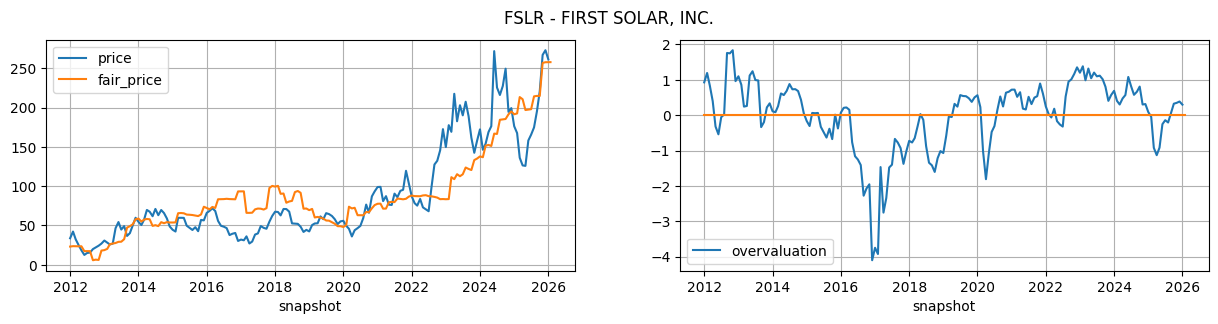

FSLR fair_price = 13.258568 * (2.280970 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -123.299726


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,2.280969,1.604716,13.258568,-123.299726,25.496468,214.746941
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.280969,1.482360,13.258568,-123.299726,28.666897,256.782292
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.280969,1.522810,13.258568,-123.299726,28.732677,257.654439
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.280969,1.527980,13.258568,-123.299726,28.741084,257.765905
2026-01-24,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.280969,1.527980,13.258568,-123.299726,28.741084,257.765905


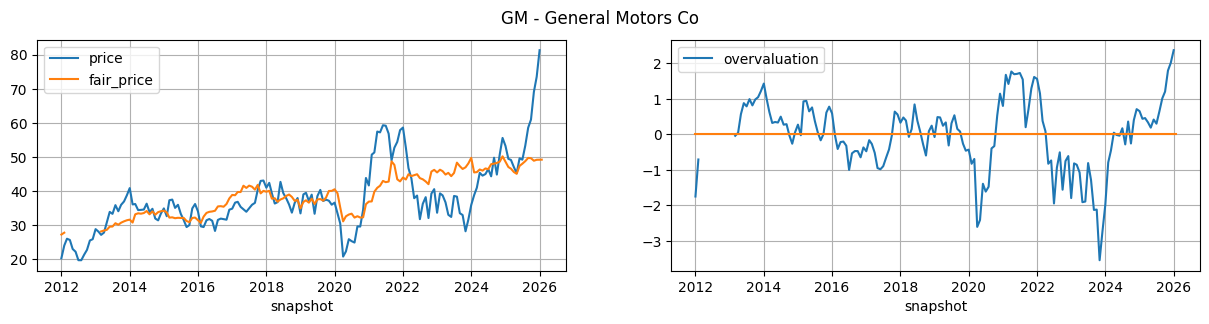

GM fair_price = 0.287401 * (1.000872 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +19.433454


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001467858,2025-06-30,GM,289.384,223.021,23.970,1.000872,1.604716,0.287401,19.433454,105.080521,49.633725
2025-11-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.000872,1.482360,0.287401,19.433454,102.516325,48.896772
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.000872,1.522810,0.287401,19.433454,103.495697,49.178245
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.000872,1.527980,0.287401,19.433454,103.620867,49.214219
2026-01-24,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.000872,1.527980,0.287401,19.433454,103.620867,49.214219


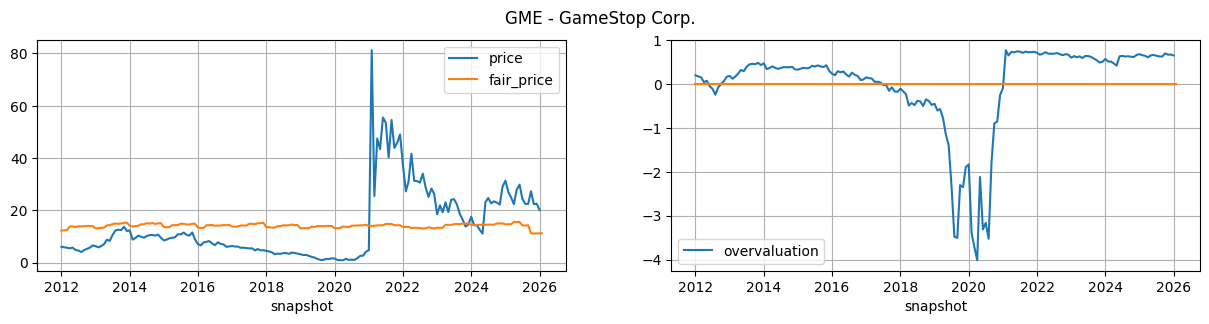

GME fair_price = 1.197638 * (0.000184 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.403368


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000184,1.604716,1.197638,16.403368,-4.365571,11.174996
2025-11-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000184,1.482360,1.197638,16.403368,-4.426357,11.102196
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000184,1.522810,1.197638,16.403368,-4.406262,11.126263
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000184,1.527980,1.197638,16.403368,-4.354179,11.188639
2026-01-24,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000184,1.527980,1.197638,16.403368,-4.354179,11.188639


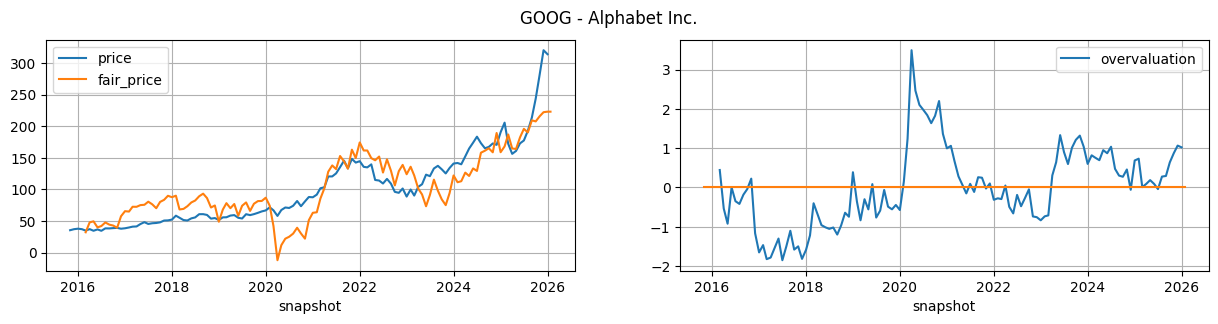

GOOG fair_price = 1.045372 * (0.243736 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +0.791786


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001652044,2025-06-30,GOOG,502.053,139.137,133.708,0.243735,1.604716,1.045372,0.791786,197.794448,207.560640
2025-11-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.243735,1.482360,1.045372,0.791786,205.619401,215.740630
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.243735,1.522810,1.045372,0.791786,211.744481,222.143619
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.243735,1.527980,1.045372,0.791786,212.527305,222.961962
2026-01-24,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.243735,1.527980,1.045372,0.791786,212.527305,222.961962


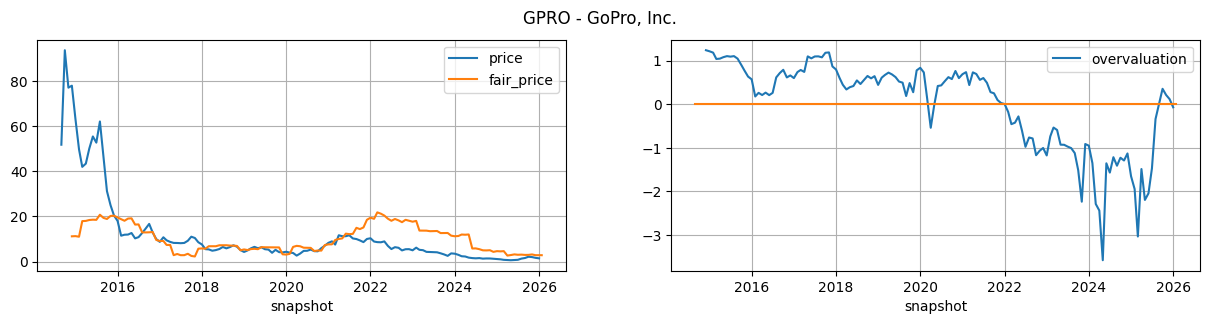

GPRO fair_price = 20.267069 * (0.824098 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +4.993732


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.824098,1.604716,20.267069,4.993732,-0.100905,2.948688
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.824098,1.482360,20.267069,4.993732,-0.091633,3.136600
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.824098,1.522810,20.267069,4.993732,-0.107705,2.810876
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.824098,1.527980,20.267069,4.993732,-0.108022,2.804446
2026-01-24,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.824098,1.527980,20.267069,4.993732,-0.108022,2.804446


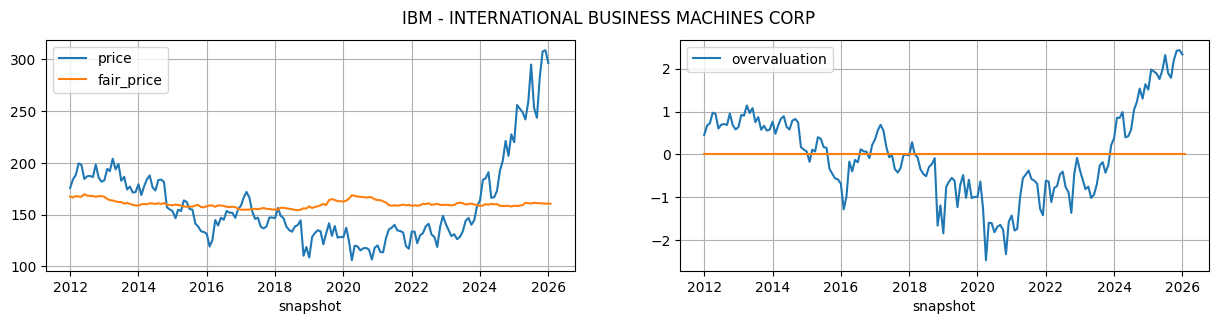

IBM fair_price = -0.234800 * (0.032906 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +138.785488


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000051143,2025-06-30,IBM,148.585,121.076,13.282,0.032906,1.604716,-0.2348,138.785488,-94.872899,161.061657
2025-11-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.032906,1.482360,-0.2348,138.785488,-93.605867,160.764158
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.032906,1.522810,-0.2348,138.785488,-93.060482,160.636102
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.032906,1.527980,-0.2348,138.785488,-92.990778,160.619735
2026-01-24,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.032906,1.527980,-0.2348,138.785488,-92.990778,160.619735


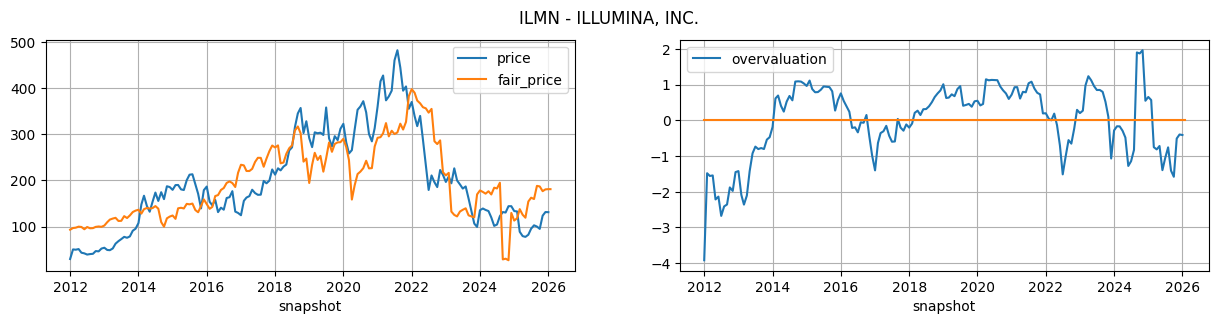

ILMN fair_price = 85.668122 * (0.398454 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +148.566757


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001110803,2025-06-29,ILMN,6.087,3.829,1.154,0.398454,1.604716,85.668122,148.566757,0.448231,186.965844
2025-11-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.398454,1.482360,85.668122,148.566757,0.328458,176.705104
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.398454,1.522810,85.668122,148.566757,0.373842,180.593129
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.398454,1.527980,85.668122,148.566757,0.379643,181.090044
2026-01-24,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.398454,1.527980,85.668122,148.566757,0.379643,181.090044


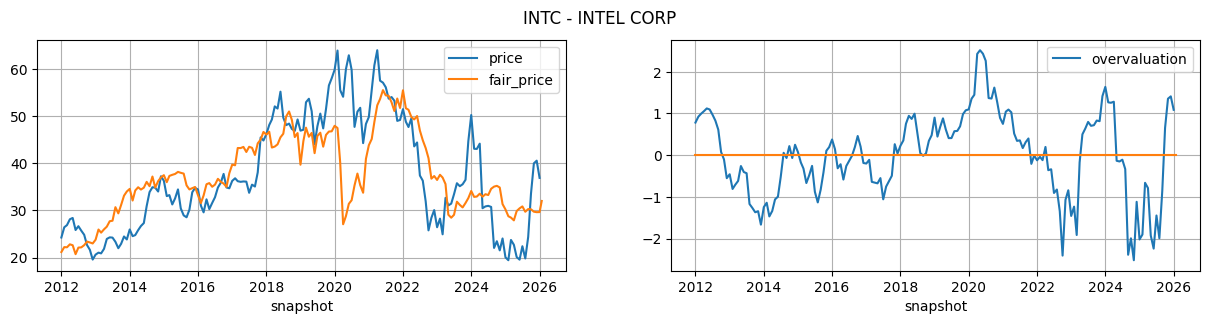

INTC fair_price = 0.414646 * (0.430240 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.423164


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.43024,1.604716,0.414646,28.423164,4.371527,30.235802
2025-11-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.43024,1.482360,0.414646,28.423164,3.137936,29.724299
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.43024,1.522810,0.414646,28.423164,2.908652,29.629226
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.43024,1.527980,0.414646,28.423164,2.952977,29.647606
2026-01-24,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.43024,1.527980,0.414646,28.423164,8.634007,32.003225


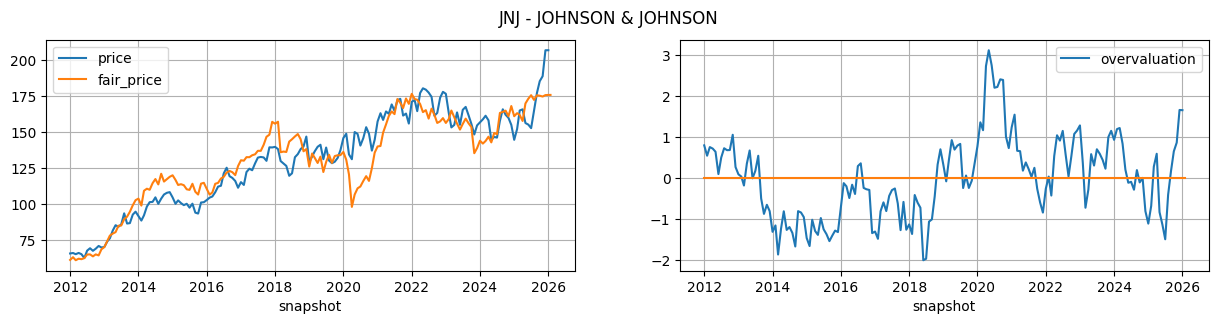

JNJ fair_price = 1.015528 * (1.506168 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -41.319535


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000200406,2025-06-29,JNJ,193.389,114.916,23.028,1.506168,1.604716,1.015528,-41.319535,213.313764,175.306649
2025-11-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.506168,1.482360,1.015528,-41.319535,212.753378,174.737561
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.506168,1.522810,1.015528,-41.319535,213.732426,175.731813
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.506168,1.527980,1.015528,-41.319535,213.857555,175.858884
2026-01-24,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.506168,1.527980,1.015528,-41.319535,213.857555,175.858884


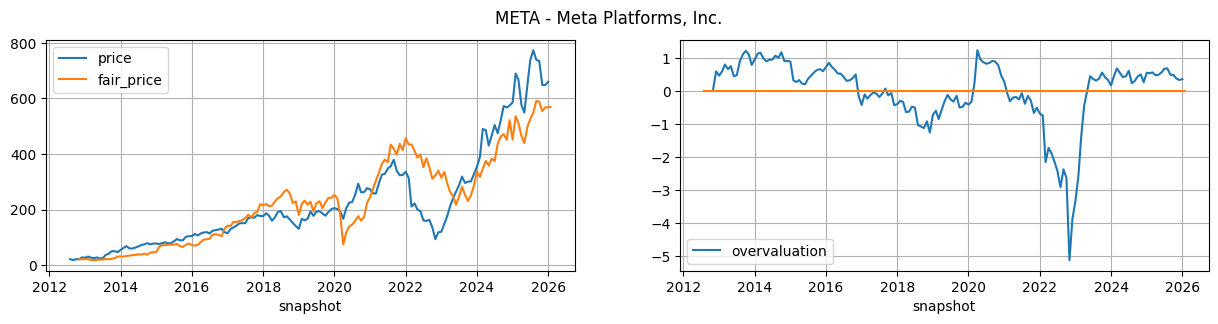

META fair_price = 3.058861 * (0.419308 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +12.343022


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326801,2025-06-30,META,294.744,99.674,102.299,0.419308,1.604716,3.058861,12.343022,188.075234,587.639073
2025-11-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.419308,1.482360,3.058861,12.343022,177.089518,554.035290
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.419308,1.522810,3.058861,12.343022,181.440871,567.345475
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.419308,1.527980,3.058861,12.343022,181.997001,569.046601
2026-01-24,0001326801,2025-09-30,META,303.844,109.778,107.574,0.419308,1.527980,3.058861,12.343022,181.997001,569.046601


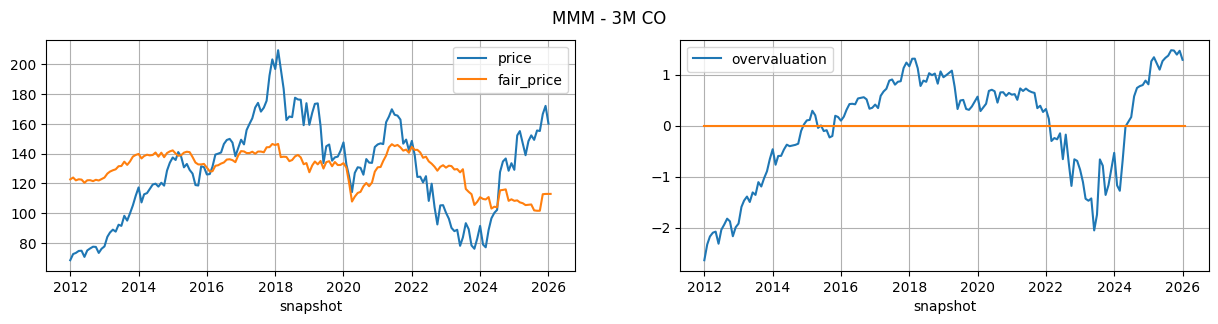

MMM fair_price = 1.876640 * (0.482629 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +133.452010


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000066740,2025-06-30,MMM,37.989,33.699,-1.002,0.482629,1.604716,1.87664,133.45201,-16.972314,101.601091
2025-11-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.482629,1.482360,1.87664,133.45201,-11.064146,112.688594
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.482629,1.522810,1.87664,133.45201,-10.961363,112.881481
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.482629,1.527980,1.87664,133.45201,-10.948227,112.906133
2026-01-24,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.482629,1.527980,1.87664,133.45201,-10.948227,112.906133


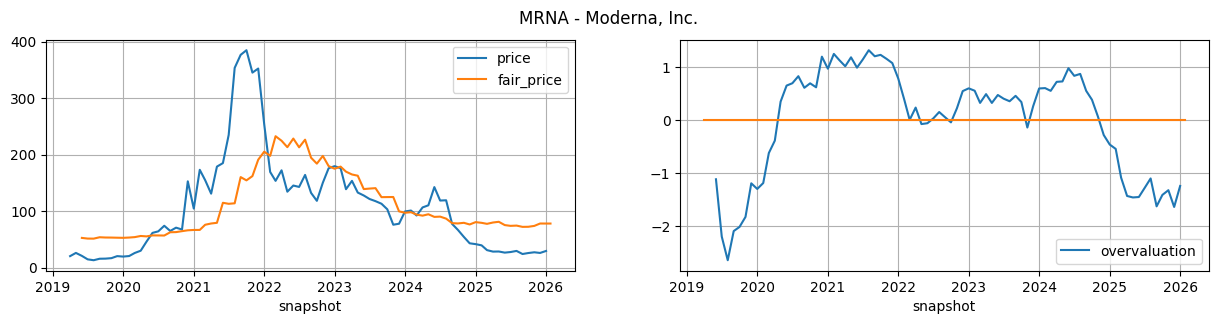

MRNA fair_price = 4.648925 * (0.966215 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +50.613900


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.966215,1.604716,4.648925,50.6139,4.665325,72.302648
2025-11-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.966215,1.482360,4.648925,50.6139,4.995319,73.836763
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.966215,1.522810,4.648925,50.6139,5.907903,78.079297
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.966215,1.527980,4.648925,50.6139,5.897677,78.031758
2026-01-24,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.966215,1.527980,4.648925,50.6139,5.897677,78.031758


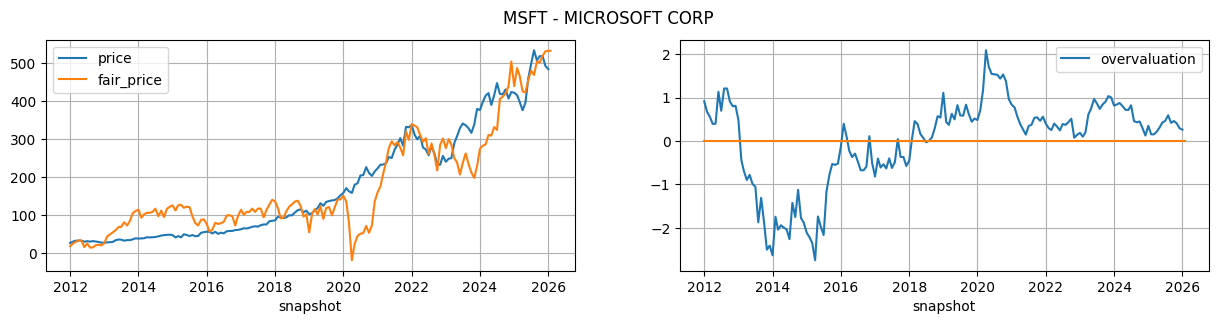

MSFT fair_price = 1.922977 * (0.446495 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +79.129832


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000789019,2025-06-30,MSFT,619.003,275.524,136.162,0.446495,1.604716,1.922977,79.129832,219.359153,500.952434
2025-11-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.446495,1.482360,1.922977,79.129832,228.817384,519.140395
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.446495,1.522810,1.922977,79.129832,234.765091,530.577698
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.446495,1.527980,1.922977,79.129832,235.525246,532.039458
2026-01-24,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.446495,1.527980,1.922977,79.129832,235.525246,532.039458


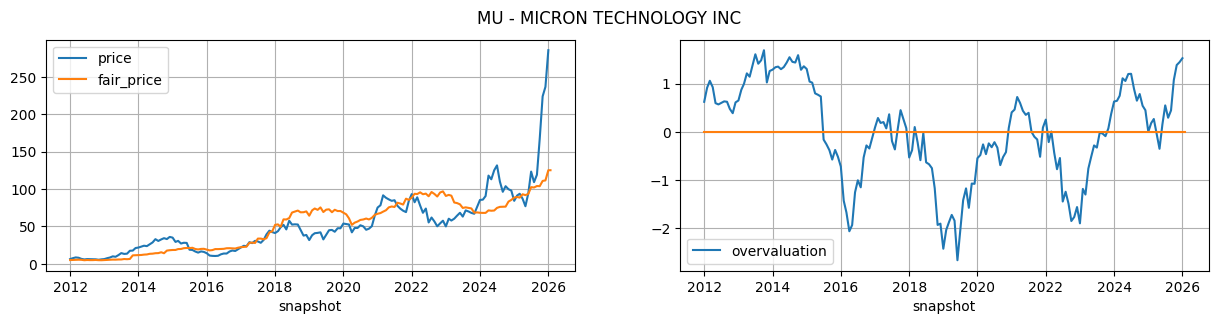

MU fair_price = 0.949257 * (1.540672 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.791897


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000723125,2025-05-29,MU,78.397,27.649,15.200,1.540672,1.604716,0.949257,-7.791897,117.526756,103.771159
2025-11-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.540672,1.482360,0.949257,-7.791897,124.909935,110.779691
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.540672,1.522810,0.949257,-7.791897,125.618818,111.452603
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.540672,1.527980,0.949257,-7.791897,139.961042,125.067054
2026-01-24,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.540672,1.527980,0.949257,-7.791897,139.961042,125.067054


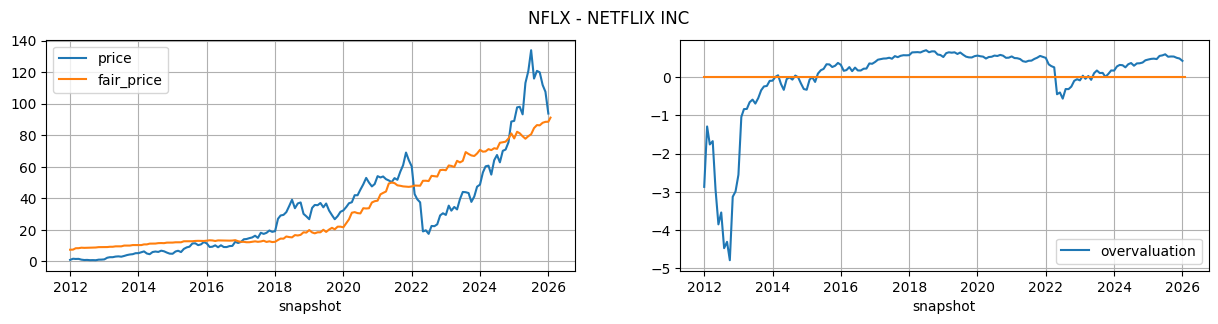

NFLX fair_price = 1.534472 * (1.231698 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +6.776117


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,1.231698,1.604716,1.534472,6.776117,51.810471,86.277835
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.231698,1.482360,1.534472,6.776117,52.875208,87.911644
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.231698,1.522810,1.534472,6.776117,53.262496,88.505927
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.231698,1.527980,1.534472,6.776117,53.311994,88.581880
2026-01-24,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.231698,1.527980,1.534472,6.776117,55.005071,91.179859


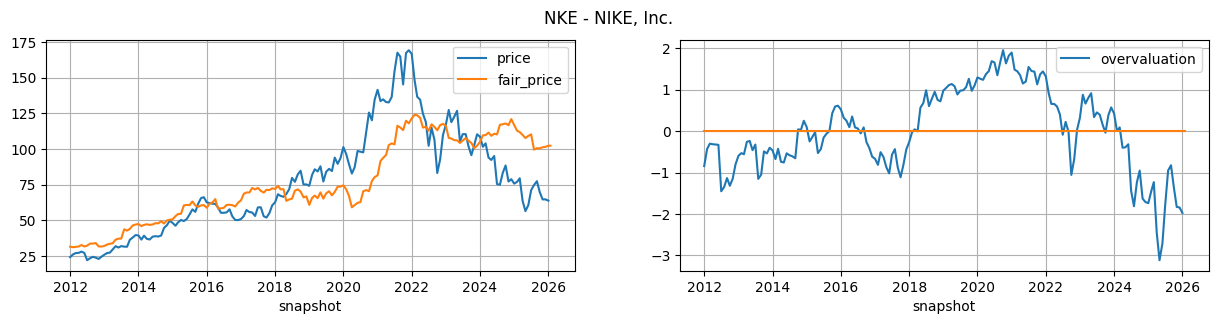

NKE fair_price = 1.929520 * (2.126072 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -16.013104


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320187,2025-05-31,NKE,36.579,23.366,3.698,2.126072,1.604716,1.92952,-16.013104,60.337833,100.409944
2025-11-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.126072,1.482360,1.92952,-16.013104,60.735580,101.177405
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.126072,1.522810,1.92952,-16.013104,60.878206,101.452605
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.126072,1.527980,1.92952,-16.013104,61.305395,102.276875
2026-01-24,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.126072,1.527980,1.92952,-16.013104,61.305395,102.276875


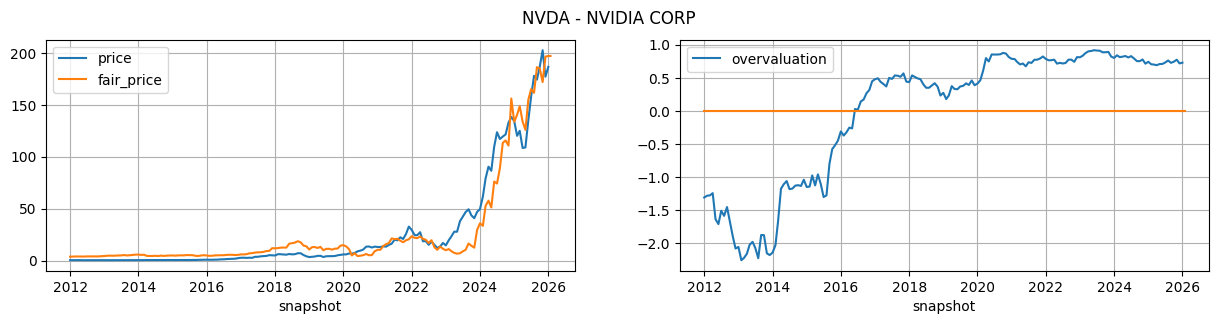

NVDA fair_price = 1.375768 * (0.342515 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +4.325530


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.342515,1.604716,1.375768,4.32553,131.215776,184.847953
2025-11-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.342515,1.482360,1.375768,4.32553,121.790104,171.880419
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.342515,1.522810,1.375768,4.32553,139.579884,196.355023
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.342515,1.527980,1.375768,4.32553,140.009795,196.946481
2026-01-24,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.342515,1.527980,1.375768,4.32553,140.009795,196.946481


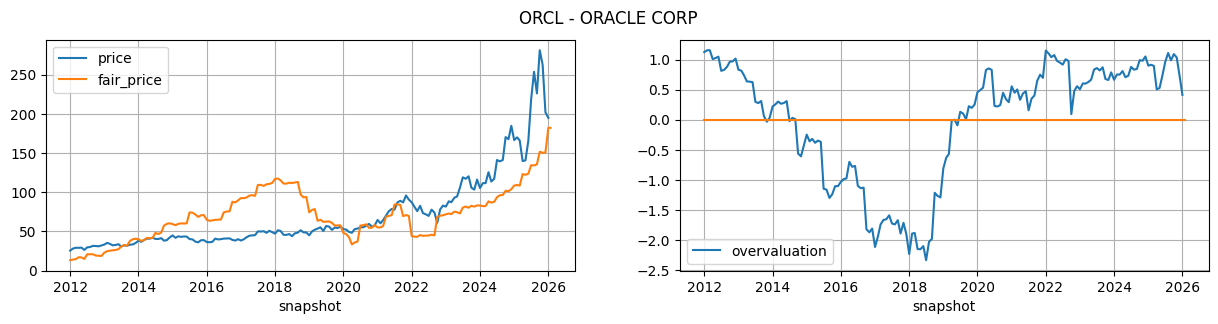

ORCL fair_price = 0.507179 * (3.237094 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -82.800658


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.237094,1.604716,0.507179,-82.800658,462.391267,151.714297
2025-11-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.237094,1.482360,0.507179,-82.800658,459.756459,150.377979
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.237094,1.522810,0.507179,-82.800658,460.627506,150.819756
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.237094,1.527980,0.507179,-82.800658,522.587246,182.244410
2026-01-24,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.237094,1.527980,0.507179,-82.800658,522.587246,182.244410


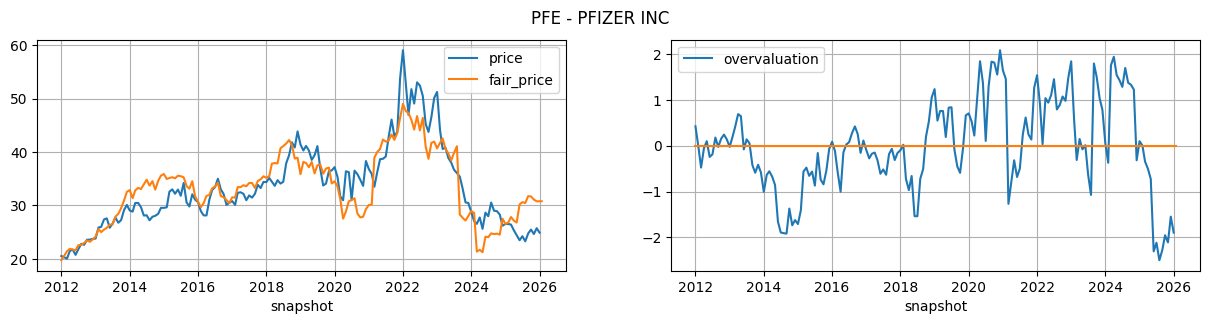

PFE fair_price = 0.311993 * (0.019263 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +59.470069


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.019263,1.604716,0.311993,59.470069,-89.057481,31.684800
2025-11-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.019263,1.482360,0.311993,59.470069,-90.915819,31.105013
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.019263,1.522810,0.311993,59.470069,-91.995340,30.768210
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.019263,1.527980,0.311993,59.470069,-91.927735,30.789302
2026-01-24,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.019263,1.527980,0.311993,59.470069,-91.927735,30.789302


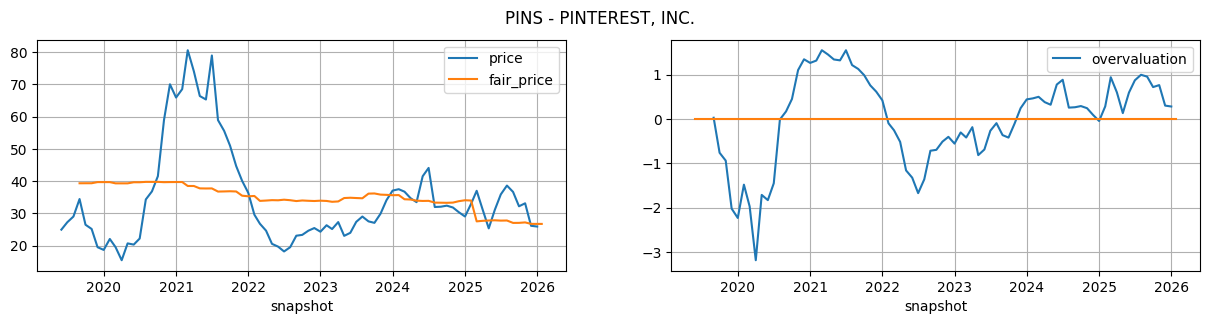

PINS fair_price = -1.069733 * (3.308345 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.359864


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.308345,1.604716,-1.069733,47.359864,19.006448,27.028048
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.308345,1.482360,-1.069733,47.359864,18.875109,27.168545
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.308345,1.522810,-1.069733,47.359864,19.303172,26.710633
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.308345,1.527980,-1.069733,47.359864,19.309102,26.704289
2026-01-24,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.308345,1.527980,-1.069733,47.359864,19.309102,26.704289


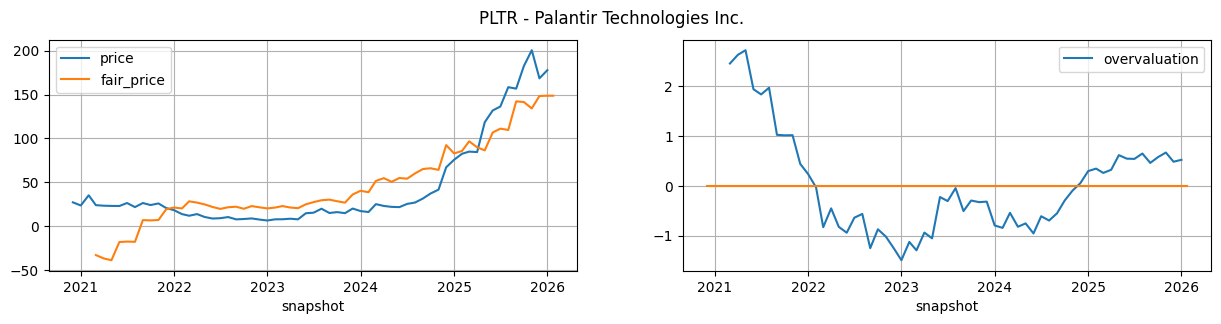

PLTR fair_price = 34.536824 * (0.392055 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.532697


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.392055,1.604716,34.536824,-4.532697,4.226504,141.437324
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.392055,1.482360,34.536824,-4.532697,4.014876,134.128365
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.392055,1.522810,34.536824,-4.532697,4.425329,148.304111
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.392055,1.527980,34.536824,-4.532697,4.434725,148.628620
2026-01-24,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.392055,1.527980,34.536824,-4.532697,4.434725,148.628620


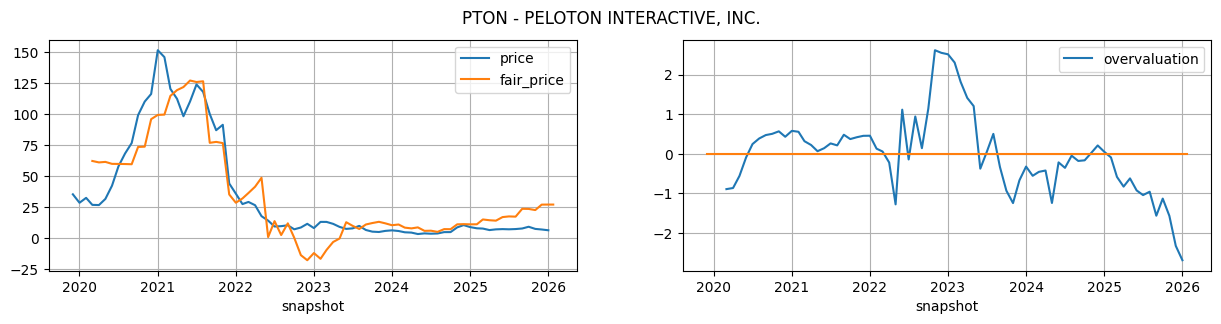

PTON fair_price = 22.851268 * (1.491408 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -3.201224


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.491408,1.604716,22.851268,-3.201224,1.164959,23.419561
2025-11-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.491408,1.482360,22.851268,-3.201224,1.124214,22.488498
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.491408,1.522810,22.851268,-3.201224,1.316954,26.892846
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.491408,1.527980,22.851268,-3.201224,1.318983,26.939203
2026-01-24,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.491408,1.527980,22.851268,-3.201224,1.318983,26.939203


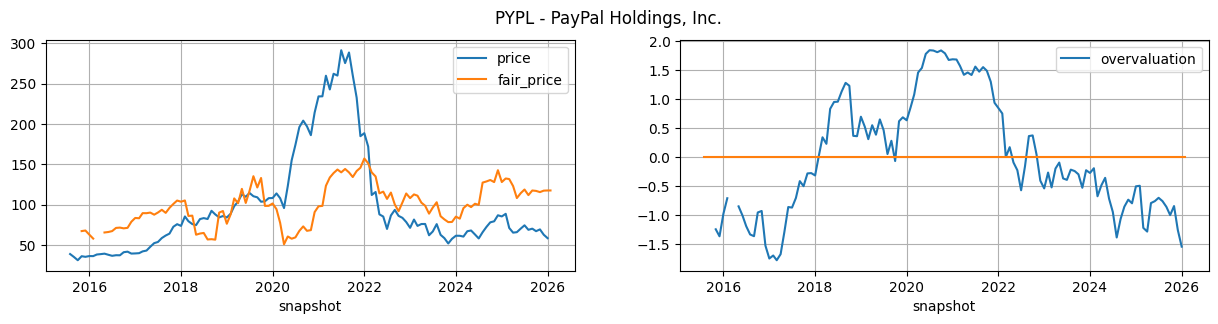

PYPL fair_price = 6.906199 * (0.865206 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -15.467115


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001633917,2025-06-30,PYPL,79.777,59.576,6.066,0.865206,1.604716,6.906199,-15.467115,19.181731,117.005725
2025-11-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.865206,1.482360,6.906199,-15.467115,18.966935,115.522307
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.865206,1.522810,6.906199,-15.467115,19.226866,117.317440
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.865206,1.527980,6.906199,-15.467115,19.260087,117.546870
2026-01-24,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.865206,1.527980,6.906199,-15.467115,19.260087,117.546870


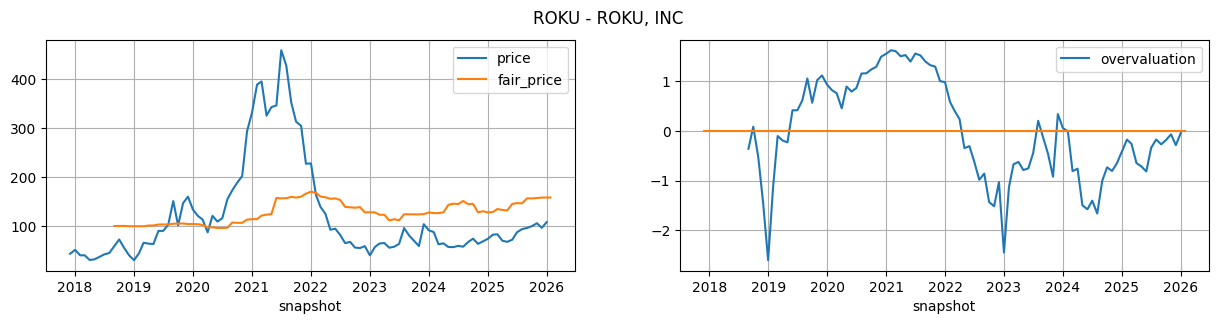

ROKU fair_price = 52.863324 * (0.497617 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +99.869476


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.497618,1.604716,52.863324,99.869476,1.075516,156.724823
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.497618,1.482360,52.863324,99.869476,1.090975,157.542020
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.497618,1.522810,52.863324,99.869476,1.109394,158.515723
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.497618,1.527980,52.863324,99.869476,1.111748,158.640168
2026-01-24,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.497618,1.527980,52.863324,99.869476,1.111748,158.640168


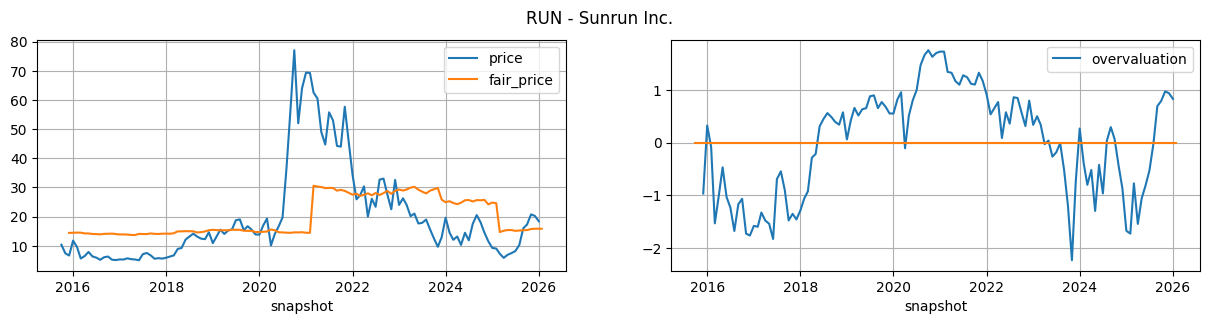

RUN fair_price = 3.556373 * (0.954848 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.012667


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.954849,1.604716,3.556373,13.012667,0.666121,15.381642
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.954849,1.482360,3.556373,13.012667,0.765398,15.734708
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.954849,1.522810,3.556373,13.012667,0.797551,15.849055
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.954849,1.527980,3.556373,13.012667,0.793535,15.834774
2026-01-24,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.954849,1.527980,3.556373,13.012667,0.793535,15.834774


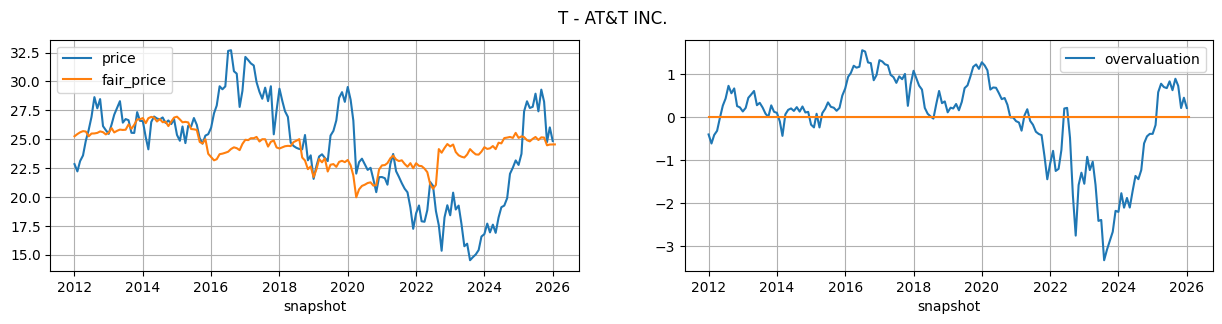

T fair_price = 0.040955 * (0.064849 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.005431


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732717,2025-06-30,T,405.491,284.097,40.943,0.064849,1.604716,0.040955,33.005431,-192.099347,25.138062
2025-11-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.064849,1.482360,0.040955,33.005431,-208.443734,24.468683
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.064849,1.522810,0.040955,33.005431,-206.790953,24.536372
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.064849,1.527980,0.040955,33.005431,-206.579717,24.545023
2026-01-24,0000732717,2025-09-30,T,423.213,296.458,40.860,0.064849,1.527980,0.040955,33.005431,-206.579717,24.545023


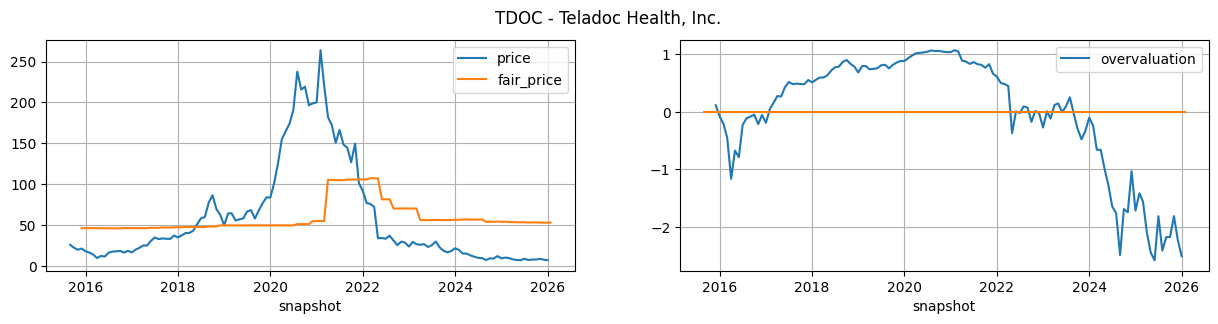

TDOC fair_price = 3.117272 * (1.190779 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.498982


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,1.190779,1.604716,3.117272,45.498982,2.461169,53.171116
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.190779,1.482360,3.117272,45.498982,2.374896,52.902179
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.190779,1.522810,3.117272,45.498982,2.386728,52.939064
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.190779,1.527980,3.117272,45.498982,2.388241,52.943778
2026-01-24,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.190779,1.527980,3.117272,45.498982,2.388241,52.943778


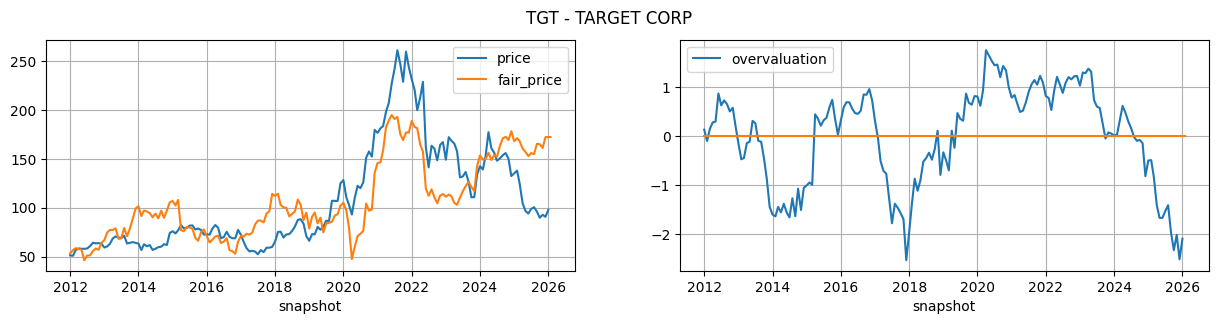

TGT fair_price = 4.983257 * (1.603049 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -136.825766


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.603049,1.604716,4.983257,-136.825766,60.554677,164.933724
2025-11-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.603049,1.482360,4.983257,-136.825766,59.773313,161.039989
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.603049,1.522810,4.983257,-136.825766,61.994000,172.106242
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.603049,1.527980,4.983257,-136.825766,62.029020,172.280755
2026-01-24,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.603049,1.527980,4.983257,-136.825766,62.029020,172.280755


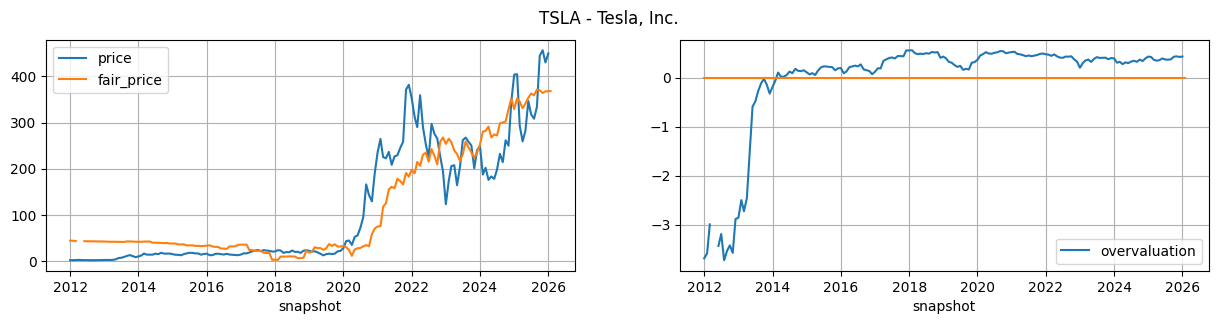

TSLA fair_price = 5.655389 * (0.652206 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +42.660843


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001318605,2025-06-30,TSLA,128.567,51.253,15.765,0.652206,1.604716,5.655389,42.660843,57.897566,370.094077
2025-11-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.652206,1.482360,5.655389,42.660843,56.802031,363.898401
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.652206,1.522810,5.655389,42.660843,57.439035,367.500908
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.652206,1.527980,5.655389,42.660843,57.520449,367.961332
2026-01-24,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.652206,1.527980,5.655389,42.660843,57.520449,367.961332


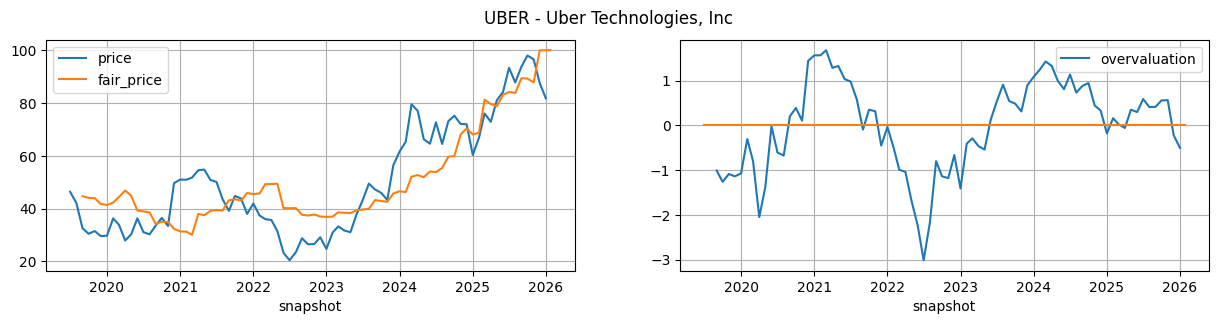

UBER fair_price = 1.342641 * (1.389402 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.673638


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.389402,1.604716,1.342641,10.673638,58.501331,89.219950
2025-11-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.389402,1.482360,1.342641,10.673638,57.425947,87.776095
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.389402,1.522810,1.342641,10.673638,66.453773,99.897229
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.389402,1.527980,1.342641,10.673638,66.500125,99.959463
2026-01-24,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.389402,1.527980,1.342641,10.673638,66.500125,99.959463


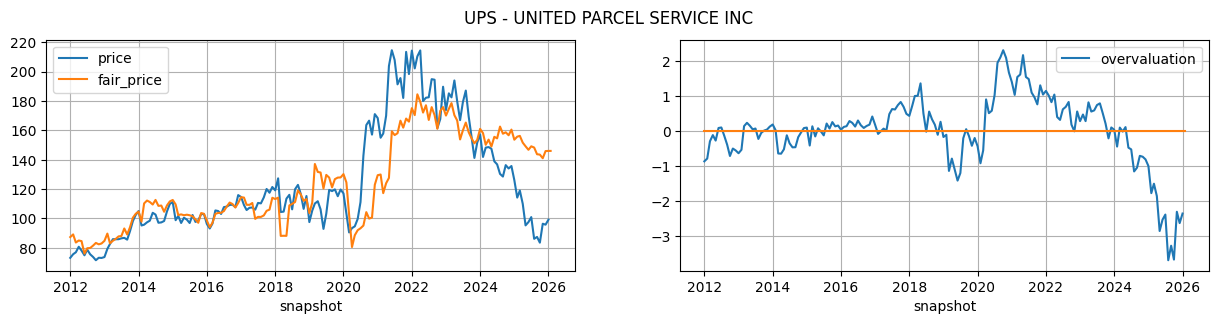

UPS fair_price = 2.700908 * (0.849572 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +97.366283


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.849572,1.604716,2.700908,97.366283,17.082889,143.505601
2025-11-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.849572,1.482360,2.700908,97.366283,16.167791,141.034004
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.849572,1.522810,2.700908,97.366283,17.971210,145.904873
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.849572,1.527980,2.700908,97.366283,18.014961,146.023042
2026-01-24,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.849572,1.527980,2.700908,97.366283,18.014961,146.023042


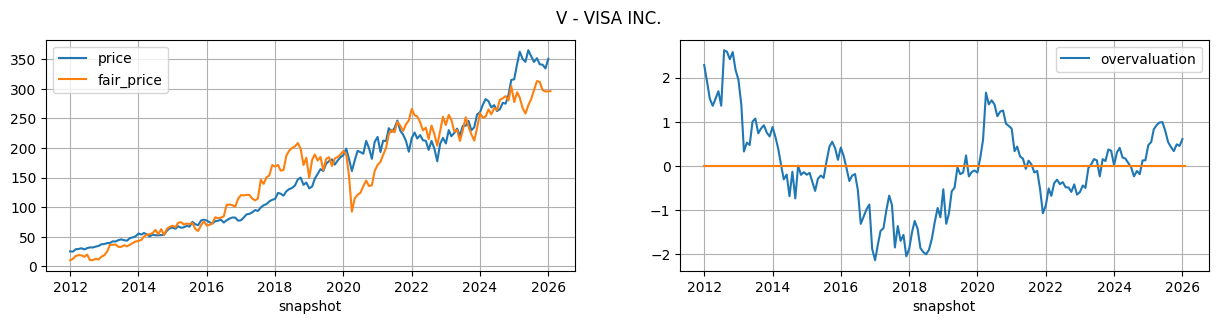

V fair_price = 4.832100 * (1.120257 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -115.366383


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.120257,1.604716,4.8321,-115.366383,88.379289,311.691151
2025-11-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.120257,1.482360,4.8321,-115.366383,85.505765,297.805998
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.120257,1.522810,4.8321,-115.366383,85.004271,295.382730
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.120257,1.527980,4.8321,-115.366383,85.123481,295.958761
2026-01-24,0001403161,2025-09-30,V,99.627,61.718,23.059,1.120257,1.527980,4.8321,-115.366383,85.123481,295.958761


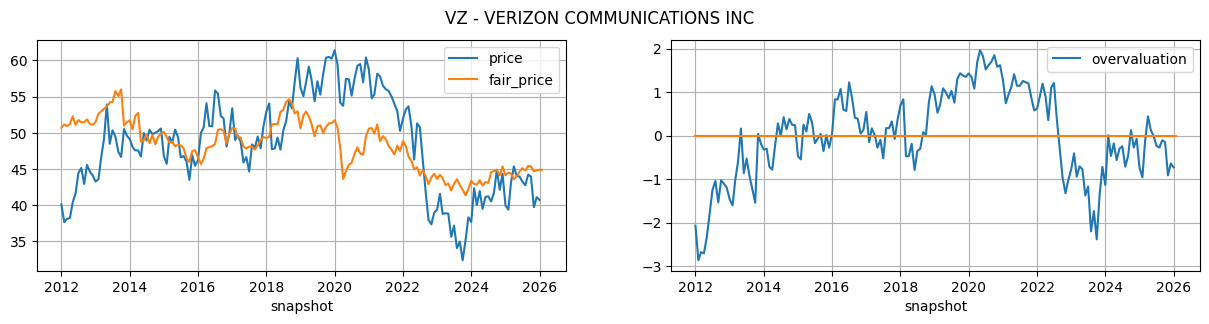

VZ fair_price = 0.126697 * (0.012172 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +72.574317


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,0.012172,1.604716,0.126697,72.574317,-214.723660,45.369500
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.012172,1.482360,0.126697,72.574317,-220.255038,44.668692
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.012172,1.522810,0.126697,72.574317,-218.699539,44.865769
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.012172,1.527980,0.126697,72.574317,-218.500736,44.890956
2026-01-24,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.012172,1.527980,0.126697,72.574317,-218.500736,44.890956


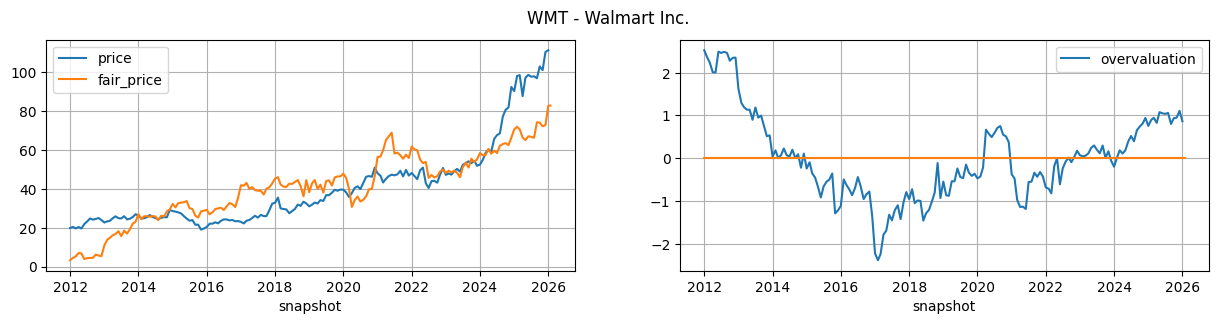

WMT fair_price = 0.400130 * (1.843106 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -77.972977


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.843106,1.604716,0.40013,-77.972977,380.136338,74.130845
2025-11-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.843106,1.482360,0.40013,-77.972977,375.433230,72.248992
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.843106,1.522810,0.40013,-77.972977,376.988041,72.871118
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.843106,1.527980,0.40013,-77.972977,402.072758,82.908257
2026-01-24,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.843106,1.527980,0.40013,-77.972977,402.072758,82.908257


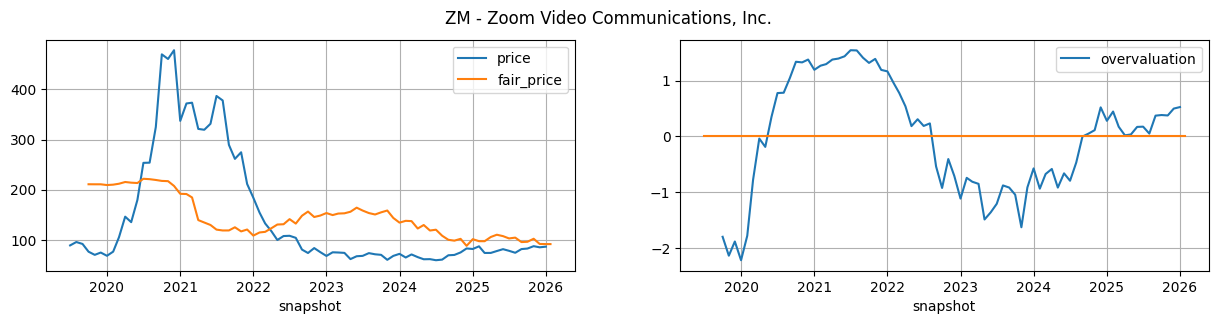

ZM fair_price = -25.638411 * (0.328898 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +214.167110


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.328898,1.604716,-25.638411,214.16711,4.608180,96.020702
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.328898,1.482360,-25.638411,214.16711,4.374115,102.021744
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.328898,1.522810,-25.638411,214.16711,4.778051,91.665470
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.328898,1.527980,-25.638411,214.16711,4.788696,91.392549
2026-01-24,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.328898,1.527980,-25.638411,214.16711,4.788696,91.392549


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['fair_price'] = df['fair_model'] * df['slope'] + df['intercept']
    df['overvaluation'] = -1 * preprocessing.scale(df['fair_price']/df['price'])

    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['slope'].mean(), df['asmul'].mean(),
        "+" if df['intercept'].mean() >= 0 else "", df['intercept'].mean()
    ))

    # Display a few most recent records from the resultset
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [18]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.918116
fair_price  0.918116    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.012172,-1.177881,-172.796286,0.126697,72.574317,-172.796286,50.681567,-2.074053
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.012172,-1.050753,-169.012826,0.126697,72.574317,-169.012826,51.160920,-2.867156
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.012172,-0.976191,-170.818773,0.126697,72.574317,-170.818773,50.932112,-2.683590
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.012172,-0.903641,-168.658232,0.126697,72.574317,-168.658232,51.205846,-2.708281
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.012172,-0.926214,-160.223212,0.126697,72.574317,-160.223212,52.274537,-2.334816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,43.95,0.012172,1.604716,-214.723660,0.126697,72.574317,-214.723660,45.369500,-0.150935
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,39.74,0.012172,1.482360,-220.255038,0.126697,72.574317,-220.255038,44.668692,-0.914727
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.012172,1.522810,-218.699539,0.126697,72.574317,-218.699539,44.865769,-0.642732


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

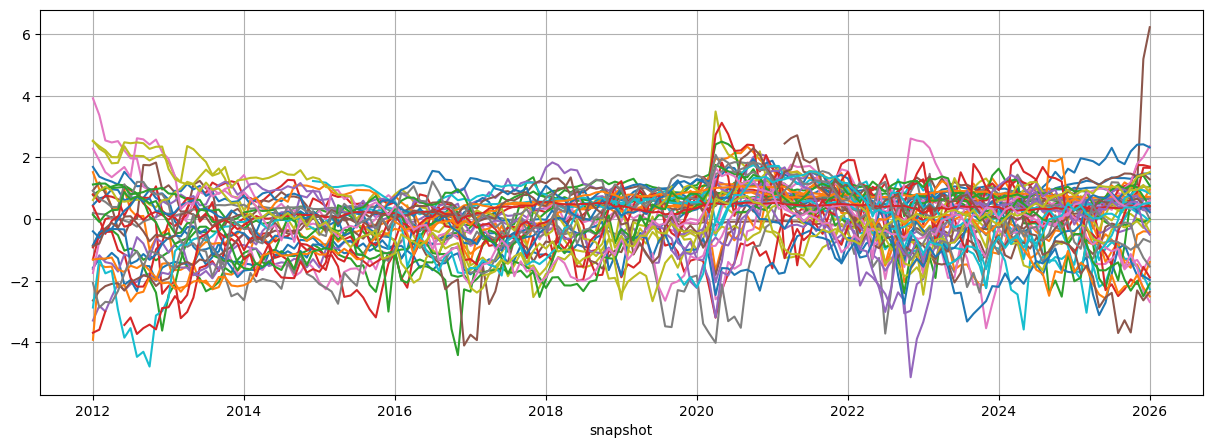

In [19]:
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [20]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.